# Access-to-Care ML Forecasting Pipeline
## Predict 2024 (Validate) → Predict 2025 (Forecast)

**Approach:**
1. **Data Preparation** — Load, clean, filter to access-barrier topics, engineer lag/trend features
2. **Phase 1: Validation** — Train on 2019–2023, predict 2024, evaluate against actuals
3. **Phase 2: Forecasting** — Retrain on 2019–2024, predict 2025
4. **Model Comparison** — Random Forest, Gradient Boosting, and Ridge regression
5. **Analysis** — Feature importance, residual diagnostics, prediction intervals

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded")

Libraries loaded


In [2]:
# Load dataset
df = pd.read_csv('Access_to_Care_Dataset.csv')
print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Time periods: {sorted(df['TIME_PERIOD'].dropna().unique())}")

Raw dataset: 26,208 rows × 25 columns
Time periods: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---
## 2. Data Cleaning & Filtering

In [3]:
# Keep essential columns
essential_cols = [
    'TOPIC', 'TAXONOMY', 'CLASSIFICATION', 'GROUP', 'SUBGROUP',
    'TIME_PERIOD', 'ESTIMATE', 'ESTIMATE_LCI', 'ESTIMATE_UCI'
]
df = df[essential_cols].copy()

# Drop rows missing the target variable
before = len(df)
df = df.dropna(subset=['ESTIMATE'])
print(f"Dropped {before - len(df):,} rows missing ESTIMATE ({(before - len(df))/before*100:.1f}%)")

# Optimize dtypes
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
for col in ['ESTIMATE', 'ESTIMATE_LCI', 'ESTIMATE_UCI']:
    df[col] = df[col].astype('float32')

# Remove duplicates
dups = df.duplicated().sum()
if dups > 0:
    df = df.drop_duplicates()
    print(f"Removed {dups} duplicates")

print(f"Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropped 2,369 rows missing ESTIMATE (9.0%)
Cleaned dataset: 23,839 rows × 9 columns


In [4]:
# Filter to access-barrier topics only
access_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
]
df = df[df['TOPIC'].isin(access_topics)].copy()
df = df.sort_values(['TOPIC', 'SUBGROUP', 'TIME_PERIOD']).reset_index(drop=True)

print(f"Access-barrier subset: {df.shape[0]:,} rows")
print(f"\nTopics ({df['TOPIC'].nunique()}):")
for t in df['TOPIC'].unique():
    n = df[df['TOPIC'] == t].shape[0]
    print(f"  • {t} ({n} rows)")
print(f"\nSubgroups: {df['SUBGROUP'].nunique()}")
print(f"Time periods: {sorted(df['TIME_PERIOD'].unique())}")

Access-barrier subset: 1,807 rows

Topics (4):
  • Delayed getting medical care due to cost among adults (454 rows)
  • Did not get needed medical care due to cost (453 rows)
  • Did not get needed mental health care due to cost (449 rows)
  • Did not take medication as prescribed to save money (451 rows)

Subgroups: 75
Time periods: [np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024)]


---
## 3. Feature Engineering

For each (TOPIC, SUBGROUP) time series, we create:
- **lag1, lag2** — Previous 1 and 2 years' ESTIMATE values
- **rolling_mean3** — 3-year rolling average
- **diff1** — Year-over-year change
- **ci_width** — Confidence interval width (proxy for measurement uncertainty; missing values imputed with topic median)

Rows with NaN features (first 2 years of each series) are dropped.

In [5]:
def make_features(data):
    """Engineer lag, trend, and uncertainty features for each time series."""
    data = data.copy()
    g = data.groupby(['TOPIC', 'SUBGROUP'])

    # Lag features
    data['lag1'] = g['ESTIMATE'].shift(1)
    data['lag2'] = g['ESTIMATE'].shift(2)

    # Rolling mean (3-year window)
    data['rolling_mean3'] = g['ESTIMATE'].transform(lambda x: x.rolling(3).mean())

    # Year-over-year difference
    data['diff1'] = g['ESTIMATE'].diff(1)

    # Confidence interval width as uncertainty proxy
    data['ci_width'] = data['ESTIMATE_UCI'] - data['ESTIMATE_LCI']

    # Impute missing ci_width with median for that TOPIC (missing CI bounds → unknown precision, not perfect precision)
    data['ci_width'] = data.groupby('TOPIC')['ci_width'].transform(
        lambda x: x.fillna(x.median())
    )

    return data

df_feat = make_features(df)

# Drop rows where lag features are NaN (first 2 years of each series)
before = len(df_feat)
df_feat = df_feat.dropna(subset=['lag1', 'lag2', 'rolling_mean3', 'diff1'])
print(f"Feature engineering complete: {len(df_feat)} rows ({before - len(df_feat)} dropped due to insufficient history)")
print(f"\nFeature columns: {[c for c in df_feat.columns if c not in df.columns]}")
print(f"Time periods remaining: {sorted(df_feat['TIME_PERIOD'].unique())}")

# Safety: replace any remaining inf values and check
for col in ['diff1', 'ci_width', 'rolling_mean3']:
    df_feat[col] = df_feat[col].replace([np.inf, -np.inf], 0)
print(f"\nInf/NaN check — any inf remaining: {np.isinf(df_feat.select_dtypes(include=np.number)).any().any()}")
print(f"Any NaN remaining: {df_feat[['lag1','lag2','rolling_mean3','diff1','ci_width']].isna().any().any()}")

Feature engineering complete: 1207 rows (600 dropped due to insufficient history)

Feature columns: ['lag1', 'lag2', 'rolling_mean3', 'diff1', 'ci_width']
Time periods remaining: [np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024)]

Inf/NaN check — any inf remaining: False
Any NaN remaining: False


---
## 4. Categorical Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder

# Store original labels before encoding
label_maps = {}
encoders = {}

for col in ['TOPIC', 'GROUP', 'SUBGROUP']:
    le = LabelEncoder()
    df_feat[col + '_encoded'] = le.fit_transform(df_feat[col])
    encoders[col] = le
    label_maps[col] = dict(zip(le.transform(le.classes_), le.classes_))
    print(f"{col}: {len(le.classes_)} categories")

# Show topic mapping for reference
print("\nTopic encoding:")
for k, v in label_maps['TOPIC'].items():
    print(f"  {k} → {v}")

TOPIC: 4 categories
GROUP: 21 categories
SUBGROUP: 74 categories

Topic encoding:
  0 → Delayed getting medical care due to cost among adults
  1 → Did not get needed medical care due to cost
  2 → Did not get needed mental health care due to cost
  3 → Did not take medication as prescribed to save money


---
## 5. Train/Test Split

**Phase 1 (Validation):** Train ≤ 2023, test on 2024 actuals  
**Phase 2 (Forecasting):** Train ≤ 2024, predict 2025

In [7]:
FEATURES = [
    'TOPIC_encoded',
    'GROUP_encoded',
    'SUBGROUP_encoded',
    'TIME_PERIOD',
    'lag1',
    'lag2',
    'rolling_mean3',
    'diff1',
    'ci_width',
]

TARGET = 'ESTIMATE'

# Phase 1 split
train_mask = df_feat['TIME_PERIOD'] <= 2023
test_mask  = df_feat['TIME_PERIOD'] == 2024

X_train = df_feat.loc[train_mask, FEATURES].copy()
y_train = df_feat.loc[train_mask, TARGET]
X_test  = df_feat.loc[test_mask, FEATURES].copy()
y_test  = df_feat.loc[test_mask, TARGET]

# Assert clean data rather than silently filling
for name, frame in [('X_train', X_train), ('X_test', X_test)]:
    n_inf = np.isinf(frame).sum().sum()
    n_nan = frame.isna().sum().sum()
    assert n_inf == 0 and n_nan == 0, f"{name} has {n_inf} inf and {n_nan} NaN values"
print("Train/test data verified: no NaN or inf values")

print(f"Phase 1 — Validation Split:")
print(f"  Train: {X_train.shape[0]} rows (2019–2023 with valid lags → mostly 2021–2023)")
print(f"  Test:  {X_test.shape[0]} rows (2024)")
print(f"  Features: {len(FEATURES)}")

Train/test data verified: no NaN or inf values
Phase 1 — Validation Split:
  Train: 905 rows (2019–2023 with valid lags → mostly 2021–2023)
  Test:  302 rows (2024)
  Features: 9


---
## 6. Phase 1 — Model Training & Validation (Predict 2024)

We compare three models:
1. **Random Forest** — Robust, handles non-linearity
2. **Gradient Boosting** — Often highest accuracy for tabular data
3. **Ridge Regression** — Simple baseline to check if complexity is warranted

In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42
    ),
    'Ridge Regression': Ridge(alpha=1.0),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)

    results[name] = {
        'model': model,
        'predictions': pred,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
    }
    print(f"{name:20s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")

Random Forest         RMSE=0.831  MAE=0.390  R²=0.9511
Gradient Boosting     RMSE=0.648  MAE=0.308  R²=0.9703
Ridge Regression      RMSE=0.002  MAE=0.002  R²=1.0000


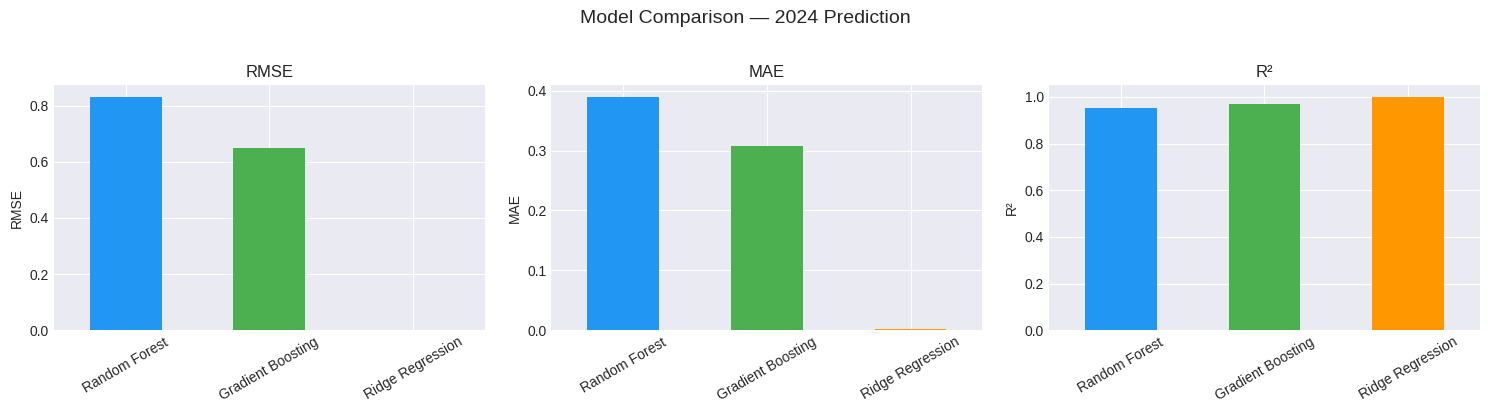


✓ Best model: Ridge Regression (R²=1.0000)


In [9]:
# Comparison bar chart
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k in ['RMSE', 'MAE', 'R²']}
    for name, vals in results.items()
}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    metrics_df[metric].plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Model Comparison — 2024 Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Select best model
best_name = max(results, key=lambda k: results[k]['R²'])
print(f"\nBest model: {best_name} (R²={results[best_name]['R²']:.4f})")

---
## 7. Validation Diagnostics

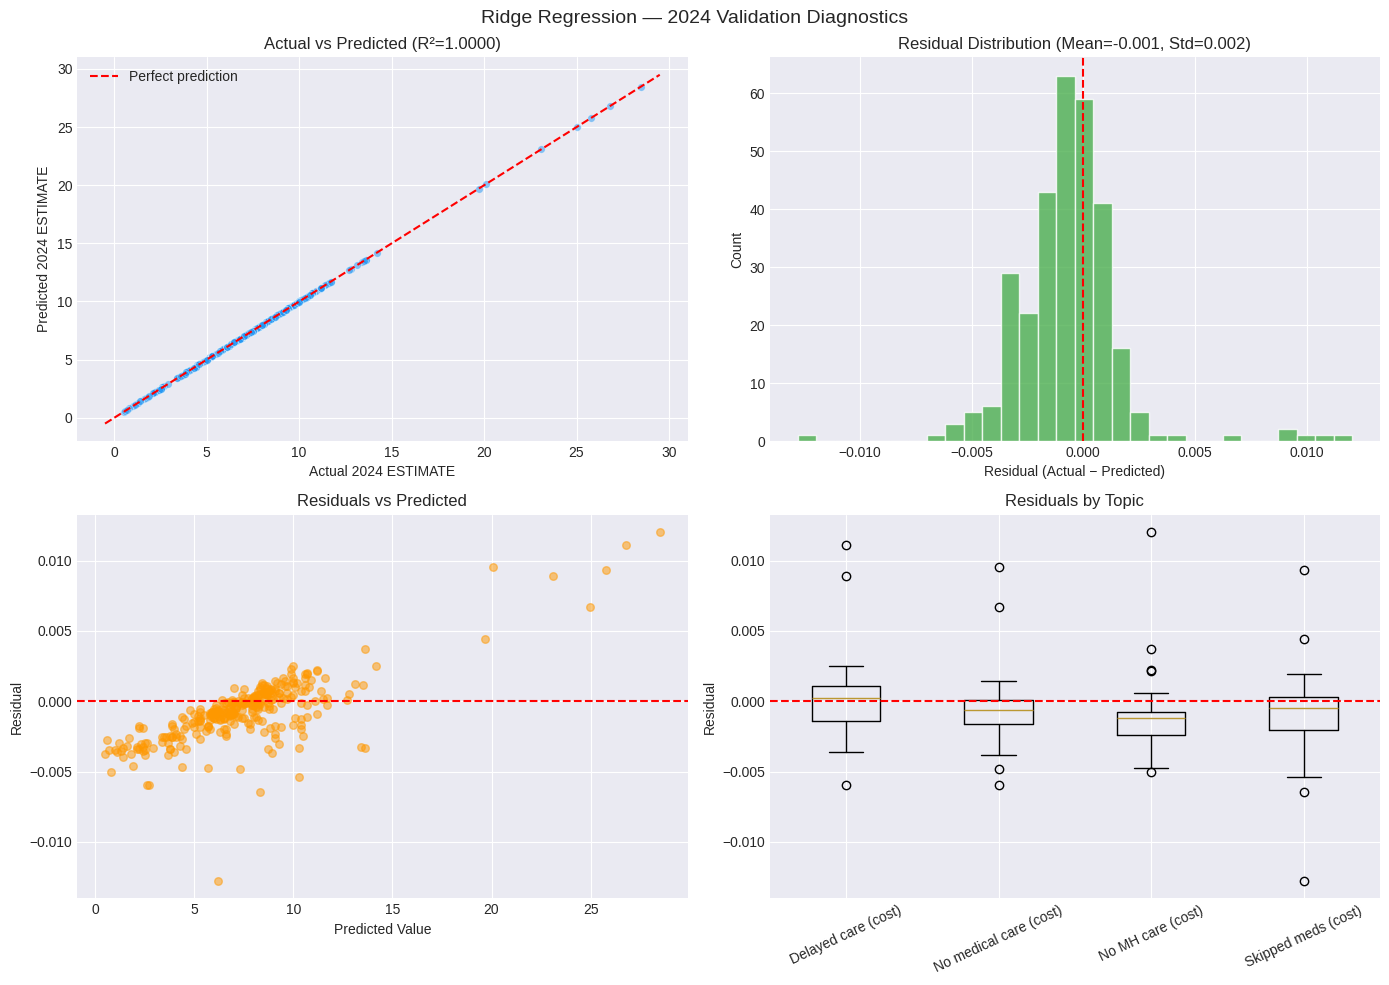

In [10]:
best = results[best_name]
pred_2024 = best['predictions']
residuals = y_test.values - pred_2024

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted scatter
ax = axes[0, 0]
ax.scatter(y_test, pred_2024, alpha=0.5, s=30, c='#2196F3', edgecolors='white', linewidth=0.5)
lims = [min(y_test.min(), pred_2024.min()) - 1, max(y_test.max(), pred_2024.max()) + 1]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual 2024 ESTIMATE')
ax.set_ylabel('Predicted 2024 ESTIMATE')
ax.set_title(f'Actual vs Predicted (R²={best["R²"]:.4f})')
ax.legend()

# Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (Mean={residuals.mean():.3f}, Std={residuals.std():.3f})')

# Residuals vs Predicted
ax = axes[1, 0]
ax.scatter(pred_2024, residuals, alpha=0.5, s=30, c='#FF9800')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# Residuals by topic
ax = axes[1, 1]
test_with_res = df_feat.loc[test_mask].copy()
test_with_res['residual'] = residuals
topic_residuals = test_with_res.groupby('TOPIC_encoded')['residual'].apply(list)
topic_labels = [encoders['TOPIC'].inverse_transform([t])[0] for t in topic_residuals.index]
# Shorten labels
short_labels = [l.replace('Delayed getting medical care due to cost among adults', 'Delayed care (cost)')
                 .replace('Did not get needed medical care due to cost', 'No medical care (cost)')
                 .replace('Did not get needed mental health care due to cost', 'No MH care (cost)')
                 .replace('Did not take medication as prescribed to save money', 'Skipped meds (cost)')
                for l in topic_labels]
ax.boxplot(topic_residuals.values, labels=short_labels)
ax.axhline(0, color='red', linestyle='--')
ax.tick_params(axis='x', rotation=25)
ax.set_ylabel('Residual')
ax.set_title('Residuals by Topic')

plt.suptitle(f'{best_name} — 2024 Validation Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

(Ridge regression uses coefficients rather than feature_importances_)


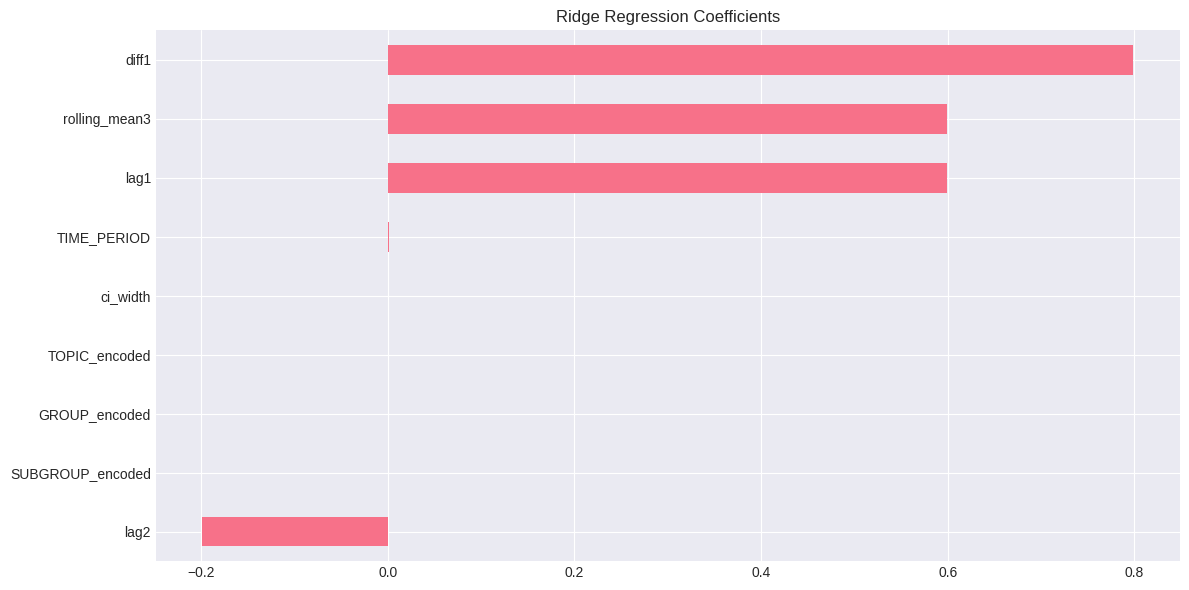

In [11]:
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=FEATURES).sort_values()

    fig, ax = plt.subplots(figsize=(10, 5))
    importances.plot(kind='barh', ax=ax, color='#2196F3')
    ax.set_title(f'{best_name} — Feature Importance')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("(Ridge regression uses coefficients rather than feature_importances_)")
    coefs = pd.Series(best['model'].coef_, index=FEATURES).sort_values()
    coefs.plot(kind='barh')
    plt.title('Ridge Regression Coefficients')
    plt.tight_layout()
    plt.show()

---
## 9. Phase 2 — Retrain on Full Data & Forecast 2025

Now that we've validated the model performs well on 2024, we retrain on **all available data (2019–2024)** and forecast 2025.

In [12]:
# Retrain best model type on 2019-2024
full_mask = df_feat['TIME_PERIOD'] <= 2024

X_full = df_feat.loc[full_mask, FEATURES].copy()
y_full = df_feat.loc[full_mask, TARGET]

assert np.isinf(X_full).sum().sum() == 0 and X_full.isna().sum().sum() == 0, "X_full has inf or NaN"
print(f"Full training data verified clean")

print(f"Full training set: {X_full.shape[0]} rows (all years with valid features)")

# Use same model class with slightly more capacity for the final model
if best_name == 'Random Forest':
    final_model = RandomForestRegressor(
        n_estimators=400, max_depth=14, random_state=42, n_jobs=-1
    )
elif best_name == 'Gradient Boosting':
    final_model = GradientBoostingRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42
    )
else:
    final_model = Ridge(alpha=1.0)

final_model.fit(X_full, y_full)
print(f"{best_name} retrained on 2019–2024 data")

Full training data verified clean
Full training set: 1207 rows (all years with valid features)
Ridge Regression retrained on 2019–2024 data


---
## 10. Construct 2025 Feature Vectors

To predict 2025, we need to build feature rows where:
- **lag1** = 2024 actual ESTIMATE (now known)
- **lag2** = 2023 actual ESTIMATE
- **rolling_mean3** = mean of 2022, 2023, 2024 actuals
- **diff1** = 2024 − 2023
- **ci_width** = 2024 CI width (best available proxy)

In [13]:
# Get 2024 and 2023 rows for building 2025 features
rows_2024 = df_feat.loc[df_feat['TIME_PERIOD'] == 2024].copy()
rows_2023 = df_feat.loc[df_feat['TIME_PERIOD'] == 2023].set_index(['TOPIC', 'SUBGROUP'])

forecast_rows = rows_2024.copy()
forecast_rows['TIME_PERIOD'] = 2025

# lag1 for 2025 = actual 2024 ESTIMATE
forecast_rows['lag1'] = rows_2024['ESTIMATE'].values

# lag2 for 2025 = actual 2023 ESTIMATE (which was lag1 in the 2024 row)
forecast_rows['lag2'] = rows_2024['lag1'].values

# rolling_mean3 for 2025 = mean of 2022, 2023, 2024 actuals
# 2024 actual = rows_2024['ESTIMATE'], 2023 = rows_2024['lag1'], 2022 = rows_2024['lag2']
forecast_rows['rolling_mean3'] = (
    rows_2024['ESTIMATE'].values +
    rows_2024['lag1'].values +
    rows_2024['lag2'].values
) / 3.0

# diff1 for 2025 = 2024 - 2023
forecast_rows['diff1'] = rows_2024['ESTIMATE'].values - rows_2024['lag1'].values

# ci_width stays from 2024 (best proxy)
# ci_width is already in forecast_rows from the copy

X_2025 = forecast_rows[FEATURES].copy()
X_2025.replace([np.inf, -np.inf], np.nan, inplace=True)  # convert inf to NaN so assertion catches both
assert X_2025.isna().sum().sum() == 0, f"2025 features have NaN: {X_2025.isna().sum()[X_2025.isna().sum() > 0].to_dict()}"
print("2025 forecast features verified clean")
print(f"2025 forecast rows: {X_2025.shape[0]}")
print(f"\nSample features for 2025:")
print(X_2025.head())

2025 forecast features verified clean
2025 forecast rows: 302

Sample features for 2025:
    TOPIC_encoded  GROUP_encoded  SUBGROUP_encoded  TIME_PERIOD  lag1  lag2  \
5               0             11                 0         2025  11.7  11.5   
11              0             18                 1         2025   8.6   7.2   
17              0              0                 2         2025  10.7   8.7   
23              0              1                 3         2025  10.6   8.8   
29              0              0                 4         2025  10.8   9.0   

    rolling_mean3     diff1  ci_width  
5       11.500000  0.200000  2.400000  
11       7.600000  1.400001  0.800000  
17       9.233334  2.000000  1.800000  
23       9.333334  1.800000  1.400001  
29       9.733333  1.800000  1.800000  


In [14]:
# Predict 2025
pred_2025 = final_model.predict(X_2025)
forecast_rows['Predicted_2025'] = pred_2025

# Decode labels for readable output
forecast_results = forecast_rows[['TOPIC_encoded', 'SUBGROUP_encoded', 'ESTIMATE', 'Predicted_2025']].copy()
forecast_results.rename(columns={'ESTIMATE': 'Actual_2024'}, inplace=True)
forecast_results['TOPIC'] = encoders['TOPIC'].inverse_transform(forecast_results['TOPIC_encoded'])
forecast_results['SUBGROUP'] = encoders['SUBGROUP'].inverse_transform(forecast_results['SUBGROUP_encoded'])
forecast_results.drop(columns=['TOPIC_encoded', 'SUBGROUP_encoded'], inplace=True)
forecast_results['Change_2024_to_2025'] = forecast_results['Predicted_2025'] - forecast_results['Actual_2024']

print(f"2025 Predictions — Summary Statistics:")
print(f"  Mean predicted value: {pred_2025.mean():.2f}")
print(f"  Median predicted value: {np.median(pred_2025):.2f}")
print(f"  Range: [{pred_2025.min():.2f}, {pred_2025.max():.2f}]")
print(f"  Mean predicted change from 2024: {forecast_results['Change_2024_to_2025'].mean():.3f}")

2025 Predictions — Summary Statistics:
  Mean predicted value: 7.72
  Median predicted value: 7.87
  Range: [-7.70, 28.70]
  Mean predicted change from 2024: 0.200


In [15]:
# Display all predictions
forecast_results_sorted = forecast_results.sort_values(
    ['TOPIC', 'Change_2024_to_2025'], ascending=[True, False]
)
print(forecast_results_sorted.to_string(index=False))

 Actual_2024  Predicted_2025                                                 TOPIC                                    SUBGROUP  Change_2024_to_2025
   10.100000       16.211471 Delayed getting medical care due to cost among adults                   Other government coverage             6.111470
    8.400000       12.773833 Delayed getting medical care due to cost among adults                                     Private             4.373834
   23.100000       26.433087 Delayed getting medical care due to cost among adults                                    Bisexual             3.333086
    8.200000        9.578627 Delayed getting medical care due to cost among adults           Little to no social vulnerability             1.378628
    8.400000        9.718576 Delayed getting medical care due to cost among adults                                     Midwest             1.318576
    6.300000        7.579306 Delayed getting medical care due to cost among adults                              

---
## 12. Forecast Visualization

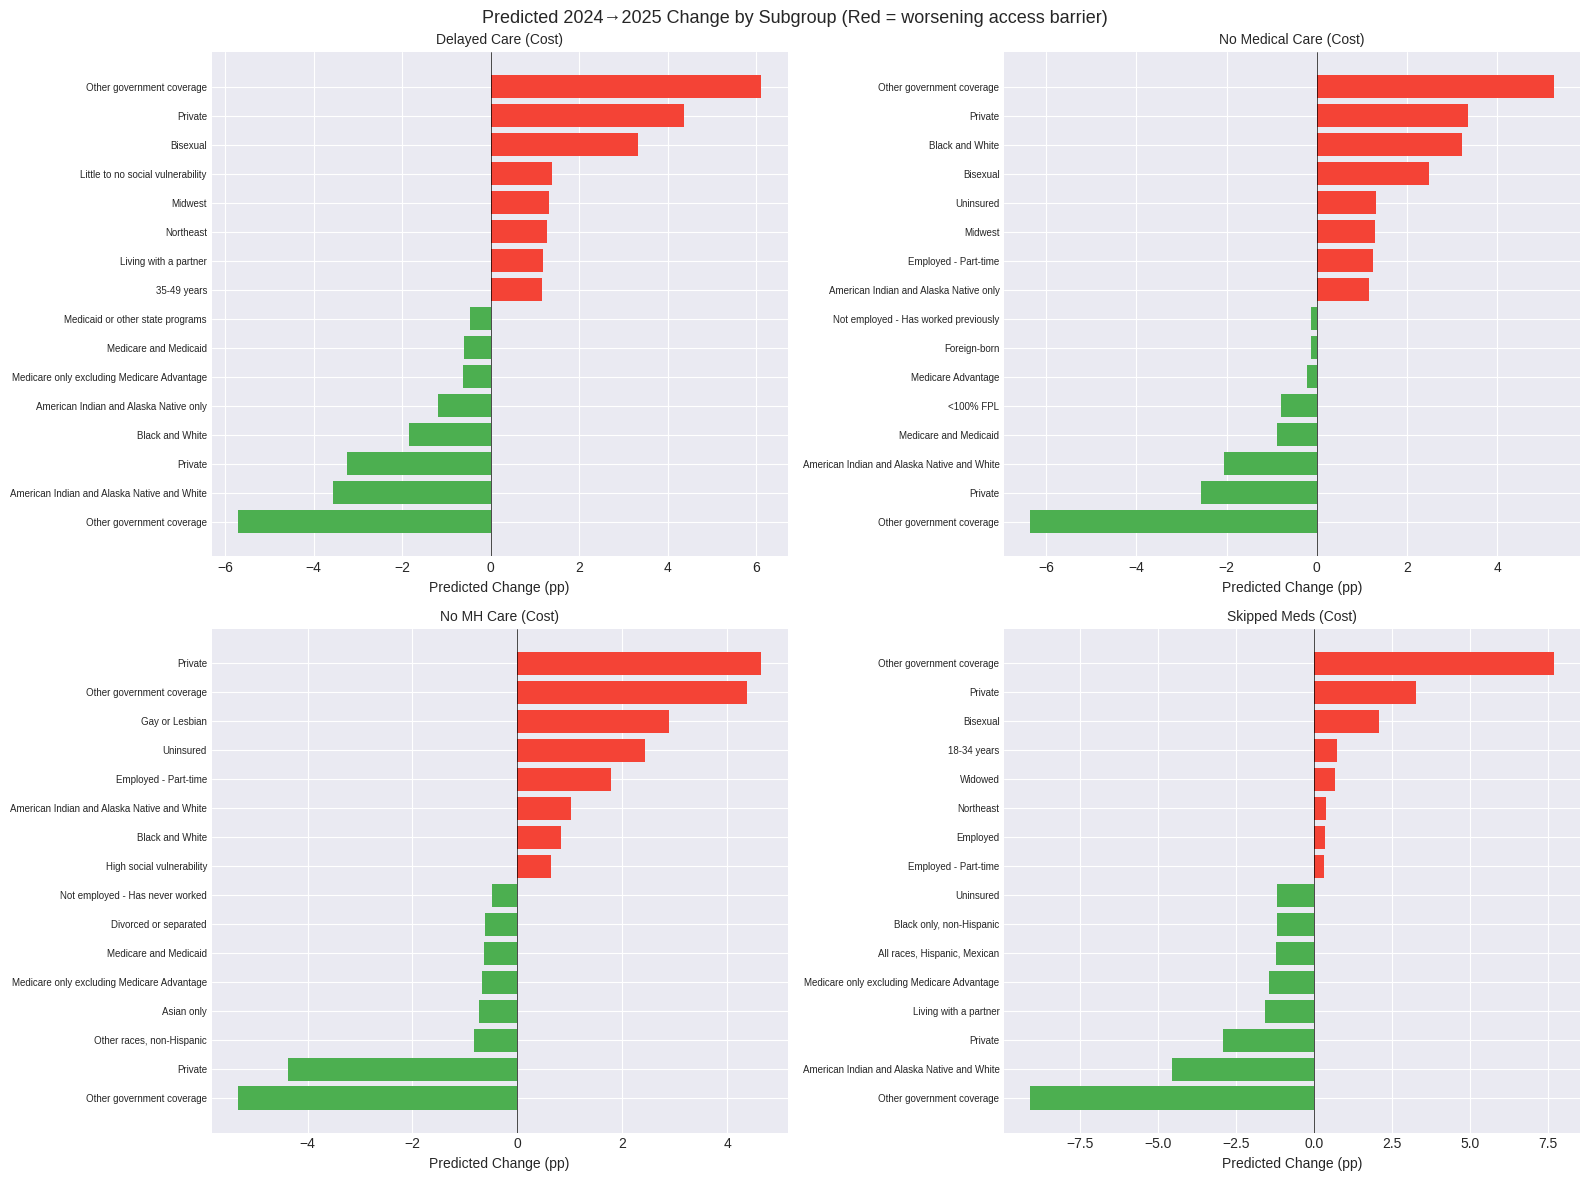

In [16]:
# Predicted change from 2024 to 2025 by topic
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

topics = forecast_results['TOPIC'].dropna().unique()
assert len(topics) > 0, "TOPIC column is all NaN — re-run from the prediction/decoding cell above"
assert all(isinstance(t, str) for t in topics), f"TOPIC values are not strings: {topics[:3]} — re-run from the prediction/decoding cell above"

for ax, topic in zip(axes.flat, topics):
    topic_data = forecast_results[forecast_results['TOPIC'] == topic].sort_values('Change_2024_to_2025')

    # Only show top/bottom movers if too many subgroups
    if len(topic_data) > 20:
        top_bottom = pd.concat([topic_data.head(8), topic_data.tail(8)])
    else:
        top_bottom = topic_data

    colors = ['#F44336' if x > 0 else '#4CAF50' for x in top_bottom['Change_2024_to_2025']]
    ax.barh(range(len(top_bottom)), top_bottom['Change_2024_to_2025'], color=colors)
    ax.set_yticks(range(len(top_bottom)))
    ax.set_yticklabels(top_bottom['SUBGROUP'], fontsize=7)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Predicted Change (pp)')

    # Shorten title
    short = topic.replace('Delayed getting medical care due to cost among adults', 'Delayed Care (Cost)')
    short = short.replace('Did not get needed medical care due to cost', 'No Medical Care (Cost)')
    short = short.replace('Did not get needed mental health care due to cost', 'No MH Care (Cost)')
    short = short.replace('Did not take medication as prescribed to save money', 'Skipped Meds (Cost)')
    ax.set_title(short, fontsize=10)

plt.suptitle('Predicted 2024→2025 Change by Subgroup (Red = worsening access barrier)', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Top 10 subgroups with largest predicted worsening
print("\nTop 10 Subgroups Predicted to WORSEN (increasing barrier):")
worst = forecast_results_sorted.sort_values('Change_2024_to_2025', ascending=False).head(10)
print(worst[['TOPIC', 'SUBGROUP', 'Actual_2024', 'Predicted_2025', 'Change_2024_to_2025']].to_string(index=False))

print("\nTop 10 Subgroups Predicted to IMPROVE (decreasing barrier):")
best_improve = forecast_results_sorted.sort_values('Change_2024_to_2025', ascending=True).head(10)
print(best_improve[['TOPIC', 'SUBGROUP', 'Actual_2024', 'Predicted_2025', 'Change_2024_to_2025']].to_string(index=False))


Top 10 Subgroups Predicted to WORSEN (increasing barrier):
                                                TOPIC                  SUBGROUP  Actual_2024  Predicted_2025  Change_2024_to_2025
  Did not take medication as prescribed to save money Other government coverage         10.3       17.989671             7.689671
Delayed getting medical care due to cost among adults Other government coverage         10.1       16.211471             6.111470
          Did not get needed medical care due to cost Other government coverage          7.3       12.553683             5.253683
    Did not get needed mental health care due to cost                   Private          6.6       11.253924             4.653924
    Did not get needed mental health care due to cost Other government coverage          5.7       10.075130             4.375130
Delayed getting medical care due to cost among adults                   Private          8.4       12.773833             4.373834
          Did not get needed m

---
## 13. Summary

| Phase | Description | Details |
|-------|-------------|---------|
| **Validation** | Train 2019–2023 → Predict 2024 | Tested against actual 2024 data |
| **Forecast** | Train 2019–2024 → Predict 2025 | Uses validated model architecture |

**Key Notes:**
- The model uses **lagged values** and **trend features** — it captures momentum and mean-reversion patterns in access-barrier metrics
- **Confidence interval width** acts as a measurement-uncertainty feature
- Predictions assume continuity with recent trends; they do not account for policy shocks or economic disruptions
- Subgroups with largest predicted changes are flagged for policy attention